# Задача 2 Статистические методы анализа ВР

## Готовим данные, делим на train, test

In [2]:
import pandas as pd

DATA_PATH = "../data/raw/train.csv"

df = pd.read_csv(DATA_PATH)

df["date"] = pd.to_datetime(df["date"])

print(df.shape)
print(df.columns.tolist())

(913000, 4)
['date', 'store', 'item', 'sales']


!pip install -U statsforecast mlforecast neuralforecast
!pip install lightgbm xgboost scikit-learn
!pip install statsmodels prophet

In [3]:
max_date = df["date"].max()

test_start = max_date - pd.Timedelta(days=89)

train_df = df[df["date"] < test_start].copy()
test_df = df[df["date"] >= test_start].copy()

print("Максимальная дата:", max_date)
print("Начало теста:", test_start)

print("\nTRAIN:")
print(train_df["date"].min(), "—", train_df["date"].max())
print("Строк:", len(train_df))

print("\nTEST:")
print(test_df["date"].min(), "—", test_df["date"].max())
print("Строк:", len(test_df))

Максимальная дата: 2017-12-31 00:00:00
Начало теста: 2017-10-03 00:00:00

TRAIN:
2013-01-01 00:00:00 — 2017-10-02 00:00:00
Строк: 868000

TEST:
2017-10-03 00:00:00 — 2017-12-31 00:00:00
Строк: 45000


In [4]:
max_date = df["date"].max()

test_start = max_date - pd.Timedelta(days=89)
val_start = max_date - pd.Timedelta(days=179)

train_df = df[df["date"] < val_start].copy()

val_df = df[
    (df["date"] >= val_start) &
    (df["date"] < test_start)
].copy()

test_df = df[
    df["date"] >= test_start
].copy()

print("TRAIN:")
print(train_df["date"].min(), "—", train_df["date"].max())
print("Строк:", len(train_df))

print("\nVALIDATION:")
print(val_df["date"].min(), "—", val_df["date"].max())
print("Строк:", len(val_df))

print("\nTEST:")
print(test_df["date"].min(), "—", test_df["date"].max())
print("Строк:", len(test_df))

TRAIN:
2013-01-01 00:00:00 — 2017-07-04 00:00:00
Строк: 823000

VALIDATION:
2017-07-05 00:00:00 — 2017-10-02 00:00:00
Строк: 45000

TEST:
2017-10-03 00:00:00 — 2017-12-31 00:00:00
Строк: 45000


In [5]:
print("Количество наблюдений:")
print("TRAIN:", len(train_df))
print("VALIDATION:", len(val_df))
print("TEST:", len(test_df))

print("\nКоличество уникальных рядов:")
print("TRAIN:", train_df[["store", "item"]].drop_duplicates().shape[0])
print("VALIDATION:", val_df[["store", "item"]].drop_duplicates().shape[0])
print("TEST:", test_df[["store", "item"]].drop_duplicates().shape[0])

print("\nПериоды:")
print("TRAIN:", train_df["date"].min(), "—", train_df["date"].max())
print("VAL:  ", val_df["date"].min(), "—", val_df["date"].max())
print("TEST: ", test_df["date"].min(), "—", test_df["date"].max())

Количество наблюдений:
TRAIN: 823000
VALIDATION: 45000
TEST: 45000

Количество уникальных рядов:
TRAIN: 500
VALIDATION: 500
TEST: 500

Периоды:
TRAIN: 2013-01-01 00:00:00 — 2017-07-04 00:00:00
VAL:   2017-07-05 00:00:00 — 2017-10-02 00:00:00
TEST:  2017-10-03 00:00:00 — 2017-12-31 00:00:00


In [6]:
def prepare_forecast_format(data):
    result = data.copy()

    result["unique_id"] = (
        result["store"].astype(str)
        + "_"
        + result["item"].astype(str)
    )

    result = result.rename(
        columns={
            "date": "ds",
            "sales": "y"
        }
    )

    result = result[
        ["unique_id", "ds", "y"]
    ].sort_values(
        ["unique_id", "ds"]
    ).reset_index(drop=True)

    return result

In [7]:
train_ts = prepare_forecast_format(train_df)
val_ts = prepare_forecast_format(val_df)
test_ts = prepare_forecast_format(test_df)

print("TRAIN:", train_ts.shape)
print("VAL:", val_ts.shape)
print("TEST:", test_ts.shape)

print(train_ts.head())

# Импортируем модели

In [10]:
from statsforecast import StatsForecast

from statsforecast.models import (
    Naive,
    SeasonalNaive,
    ARIMA,
    AutoARIMA,
    AutoETS,
    Theta,
    AutoTheta,
    HoltWinters
)

print("Все импорты работают!")

ModuleNotFoundError: No module named 'statsforecast'

In [11]:
from statsforecast import StatsForecast
from statsforecast.models import Naive

sf_test = StatsForecast(
    models=[Naive()],
    freq="D",
    n_jobs=-1
)

forecast_test = sf_test.forecast(
    df=train_ts,
    h=90
)

print(forecast_test.shape)
print(forecast_test.head())

(45000, 3)
  unique_id         ds  Naive
0      10_1 2017-07-05   36.0
1      10_1 2017-07-06   36.0
2      10_1 2017-07-07   36.0
3      10_1 2017-07-08   36.0
4      10_1 2017-07-09   36.0


print("TRAIN:", train_ts.shape)
print("VAL:", val_ts.shape)
print("TEST:", test_ts.shape)

print("Количество рядов:")
print("TRAIN:", train_ts["unique_id"].nunique())
print("VAL:", val_ts["unique_id"].nunique())
print("TEST:", test_ts["unique_id"].nunique())

# Проверяем базовые модели

In [12]:
from statsforecast import StatsForecast
from statsforecast.models import Naive, SeasonalNaive

baseline_models = [
    Naive(),
    SeasonalNaive(season_length=7)
]

sf_baseline = StatsForecast(
    models=baseline_models,
    freq="D",
    n_jobs=-1
)

baseline_forecast = sf_baseline.forecast(
    df=train_ts,
    h=90
)

print(baseline_forecast.shape)
print(baseline_forecast.head())

(45000, 4)
  unique_id         ds  Naive  SeasonalNaive
0      10_1 2017-07-05   36.0           28.0
1      10_1 2017-07-06   36.0           40.0
2      10_1 2017-07-07   36.0           34.0
3      10_1 2017-07-08   36.0           38.0
4      10_1 2017-07-09   36.0           40.0


In [13]:
val_actual = val_ts[
    ["unique_id", "ds", "y"]
].copy()

results = val_actual.merge(
    baseline_forecast,
    on=["unique_id", "ds"],
    how="left"
)

print(results.head())
print(results.shape)

  unique_id         ds   y  Naive  SeasonalNaive
0      10_1 2017-07-05  40   36.0           28.0
1      10_1 2017-07-06  24   36.0           40.0
2      10_1 2017-07-07  40   36.0           34.0
3      10_1 2017-07-08  39   36.0           38.0
4      10_1 2017-07-09  42   36.0           40.0
(45000, 5)


In [14]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

def calculate_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)

    rmse = np.sqrt(
        mean_squared_error(y_true, y_pred)
    )

    mask = y_true != 0

    mape = (
        np.mean(
            np.abs(
                (y_true[mask] - y_pred[mask])
                / y_true[mask]
            )
        ) * 100
    )

    return mae, rmse, mape

In [15]:
metrics = []

for model_name in ["Naive", "SeasonalNaive"]:
    mae, rmse, mape = calculate_metrics(
        results["y"].values,
        results[model_name].values
    )

    metrics.append({
        "model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "MAPE": mape
    })

baseline_results = pd.DataFrame(metrics)

baseline_results.sort_values("MAE")

,model,MAE,RMSE,MAPE
1,SeasonalNaive,11.591733,15.179079,20.258857
0,Naive,12.253933,15.998719,21.457995


## Вывод

В качестве базовых методов были рассмотрены Naive и SeasonalNaive с недельным сезонным периодом 7 дней. SeasonalNaive продемонстрировал лучшее качество по всем рассматриваемым метрикам: MAE = 11.59, RMSE = 15.18 и MAPE = 20.26%, против 12.25, 16.00 и 21.46% у Naive. Таким образом, использование сезонного значения предыдущей недели позволяет повысить точность прогнозирования. Полученный результат подтверждает наличие выраженной недельной компоненты в исследуемых временных рядах.

In [16]:
print(train_ts.isna().sum())

print(
    train_ts.groupby("unique_id").size().value_counts().sort_index()
)

print("inf:", np.isinf(train_ts["y"]).sum())

print(train_ts.dtypes)

unique_id    0
ds           0
y            0
dtype: int64
1646    500
Name: count, dtype: int64
inf: 0
unique_id            object
ds           datetime64[ns]
y                     int64
dtype: object


In [17]:
from statsforecast import StatsForecast
from statsforecast.models import ARIMA

sf_arima = StatsForecast(
    models=[
        ARIMA(
            order=(1, 0, 1)
        )
    ],
    freq="D",
    n_jobs=1
)

forecast_arima = sf_arima.forecast(
    df=train_ts,
    h=90
)

print(forecast_arima.shape)
print(forecast_arima.head())

(45000, 3)
  unique_id         ds      ARIMA
0      10_1 2017-07-05  33.635067
1      10_1 2017-07-06  33.579224
2      10_1 2017-07-07  33.523712
3      10_1 2017-07-08  33.468536
4      10_1 2017-07-09  33.413696


In [ ]:
sf_sarima = StatsForecast(
    models=[
        ARIMA(
            order=(1, 0, 1),
            seasonal_order=(0, 1, 1),
            season_length=7
        )
    ],
    freq="D",
    n_jobs=1
)

forecast_sarima = sf_sarima.forecast(
    df=train_ts,
    h=90
)

print(forecast_sarima.shape)
print(forecast_sarima.head())


In [ ]:
from statsforecast.models import Theta

sf_theta = StatsForecast(
    models=[
        Theta(
            season_length=7
        )
    ],
    freq="D",
    n_jobs=-1
)

forecast_theta = sf_theta.forecast(
    df=train_ts,
    h=90
)

print(forecast_theta.shape)
print(forecast_theta.head())

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

def evaluate_forecast(forecast, actual, model_name):
    
    merged = actual.merge(
        forecast,
        on=["unique_id", "ds"],
        how="inner"
    )
    
    y_true = merged["y"].values
    y_pred = merged[model_name].values
    
    mae = mean_absolute_error(y_true, y_pred)
    
    rmse = np.sqrt(
        mean_squared_error(y_true, y_pred)
    )
    
    mask = y_true != 0
    
    mape = (
        np.mean(
            np.abs(
                (y_true[mask] - y_pred[mask])
                / y_true[mask]
            )
        ) * 100
    )
    
    return {
        "model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "MAPE": mape
    }

In [ ]:
arima_metrics = evaluate_forecast(
    forecast_arima,
    val_ts,
    "ARIMA"
)

arima_metrics

In [ ]:
theta_metrics = evaluate_forecast(
    forecast_theta,
    val_ts,
    "Theta"
)

theta_metrics

In [ ]:
from statsforecast import StatsForecast
from statsforecast.models import HoltWinters

sf_hw = StatsForecast(
    models=[
        HoltWinters(
            season_length=7
        )
    ],
    freq="D",
    n_jobs=-1
)

forecast_hw = sf_hw.forecast(
    df=train_ts,
    h=90
)

print(forecast_hw.shape)
print(forecast_hw.head())

In [ ]:
hw_metrics = evaluate_forecast(
    forecast_hw,
    val_ts,
    "HoltWinters"
)

hw_metrics

In [ ]:
from statsforecast import StatsForecast
from statsforecast.models import AutoETS

sf_autoets = StatsForecast(
    models=[
        AutoETS(
            season_length=7
        )
    ],
    freq="D",
    n_jobs=-1
)

forecast_autoets = sf_autoets.forecast(
    df=train_ts,
    h=90
)

print(forecast_autoets.shape)
print(forecast_autoets.head())

In [ ]:
autoets_metrics = evaluate_forecast(
    forecast_autoets,
    val_ts,
    "AutoETS"
)

autoets_metrics

In [ ]:
from statsforecast import StatsForecast
from statsforecast.models import AutoTheta

sf_autotheta = StatsForecast(
    models=[
        AutoTheta(
            season_length=7
        )
    ],
    freq="D",
    n_jobs=-1
)

forecast_autotheta = sf_autotheta.forecast(
    df=train_ts,
    h=90
)

print(forecast_autotheta.shape)
print(forecast_autotheta.head())

In [ ]:
autotheta_metrics = evaluate_forecast(
    forecast_autotheta,
    val_ts,
    "AutoTheta"
)

autotheta_metrics

## Вывод
Модель               Режим       MAE ↓                RMSE ↓               MAPE ↓
Naive baseline                  12.254                15.999              21.458%
SeasonalNaive(7) baseline       11.592                15.179              20.259%
Holt-Winters        ручной       10.464               13.472              18.558%
AutoETS     автоматический       10.152               13.205              17.723%
Theta               ручной        9.718                 12.624             16.940%
ARIMA (1:0:1)       ручной        10.021                13,282             16.287%
AutoTheta   автоматический        9.866                 12.802             17.226%

На первоначальной валидационной выборке лучшим методом по MAE и RMSE оказался Theta (MAE = 9.718, RMSE = 12.624). Минимальное значение MAPE показала ручная ARIMA (16.827%), однако по MAE и RMSE она уступила Theta. AutoTheta продемонстрировала близкий к Theta результат (MAE = 9.866; RMSE = 12.802), а AutoETS превзошла ручную Holt-Winters. Таким образом, предварительный выбор между Theta и ARIMA требует дополнительной проверки устойчивости результатов на нескольких временных срезах.




# Задача 3 Применение ML моделей для прогнозирования

## Готовим проверяем данные, горизонт прогнозирования (h=90)

In [8]:
print("TRAIN")
print(train_ts.shape)
print(train_ts.head())

print("\nVALIDATION")
print(val_ts.shape)
print(val_ts.head())

print("\nTEST")
print(test_ts.shape)
print(test_ts.head())

TRAIN
(823000, 3)
  unique_id         ds   y
0      10_1 2013-01-01  14
1      10_1 2013-01-02  14
2      10_1 2013-01-03  16
3      10_1 2013-01-04  17
4      10_1 2013-01-05  12

VALIDATION
(45000, 3)
  unique_id         ds   y
0      10_1 2017-07-05  40
1      10_1 2017-07-06  24
2      10_1 2017-07-07  40
3      10_1 2017-07-08  39
4      10_1 2017-07-09  42

TEST
(45000, 3)
  unique_id         ds   y
0      10_1 2017-10-03  28
1      10_1 2017-10-04  25
2      10_1 2017-10-05  36
3      10_1 2017-10-06  30
4      10_1 2017-10-07  41


In [9]:
print(
    "Train:",
    train_ts["ds"].min(),
    "→",
    train_ts["ds"].max()
)

print(
    "Validation:",
    val_ts["ds"].min(),
    "→",
    val_ts["ds"].max()
)

print(
    "Test:",
    test_ts["ds"].min(),
    "→",
    test_ts["ds"].max()
)

Train: 2013-01-01 00:00:00 → 2017-07-04 00:00:00
Validation: 2017-07-05 00:00:00 → 2017-10-02 00:00:00
Test: 2017-10-03 00:00:00 → 2017-12-31 00:00:00


In [10]:
print(
    "Дней validation:",
    val_ts["ds"].nunique()
)

print(
    "Дней test:",
    test_ts["ds"].nunique()
)

Дней validation: 90
Дней test: 90


In [11]:
!pip install -U mlforecast lightgbm xgboost

In [12]:
import sys

print(sys.executable)
print(sys.version)


C:\Users\VTB\anaconda3\envs\ts_dl\python.exe
3.11.15 | packaged by Anaconda, Inc. | (main, Jun 11 2026, 15:12:53) [MSC v.1942 64 bit (AMD64)]


In [13]:
!{sys.executable} -m pip show xgboost

Name: xgboost
Version: 3.2.0
Summary: XGBoost Python Package
Home-page: 
Author: 
Author-email: Hyunsu Cho <chohyu01@cs.washington.edu>, Jiaming Yuan <jm.yuan@outlook.com>
License: Apache-2.0
Location: C:\Users\VTB\anaconda3\envs\ts_dl\Lib\site-packages
Requires: numpy, scipy
Required-by: 


In [14]:
import sys

!{sys.executable} -m pip install xgboost lightgbm mlforecast

In [15]:
from xgboost import XGBRegressor

print("XGBoost работает")

XGBoost работает


In [16]:
import numpy as np
import pandas as pd


from sklearn.metrics import mean_absolute_error, mean_squared_error

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.ensemble import RandomForestRegressor

from mlforecast import MLForecast
from mlforecast.lag_transforms import RollingMean

In [17]:
models = [
    LGBMRegressor(
        n_estimators=500,
        learning_rate=0.05,
        num_leaves=31,
        random_state=42,
        verbosity=-1
    ),

    XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=8,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        objective="reg:squarederror"
    ),

    RandomForestRegressor(
        n_estimators=200,
        max_depth=15,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    )
]

In [18]:
fcst = MLForecast(
    models=models,
    freq="D",

    lags=[
        1,
        7,
        14,
        28,
        90
    ],

    lag_transforms={
        1: [
            RollingMean(window_size=7),
            RollingMean(window_size=28)
        ]
    },

    date_features=[
        "dayofweek",
        "month",
        "year"
    ]
)

In [33]:
train_val_ts = pd.concat(
    [train_ts, val_ts],
    ignore_index=True
).sort_values(
    ["unique_id", "ds"]
).reset_index(drop=True)

In [35]:
fcst.fit(train_val_ts)


MLForecast(models=[LGBMRegressor, XGBRegressor, RandomForestRegressor], freq=D, lag_features=['lag1', 'lag7', 'lag14', 'lag28', 'lag90', 'rolling_mean_lag1_window_size7', 'rolling_mean_lag1_window_size28'], date_features=['dayofweek', 'month', 'year'], num_threads=1)

In [36]:
test_pred = fcst.predict(h=HORIZON)

print(test_pred.head())
print(test_pred.shape)
print(test_pred["ds"].min())
print(test_pred["ds"].max())

  unique_id         ds  LGBMRegressor  XGBRegressor  RandomForestRegressor
0      10_1 2017-10-03      23.963143     24.034267              25.001800
1      10_1 2017-10-04      23.070595     23.646400              25.410464
2      10_1 2017-10-05      25.064052     25.165190              26.590948
3      10_1 2017-10-06      27.031812     27.345407              28.544888
4      10_1 2017-10-07      28.669043     29.043543              30.727478
(45000, 5)
2017-10-03 00:00:00
2017-12-31 00:00:00


In [37]:
test_ml = test_ts.merge(
    test_pred,
    on=["unique_id", "ds"],
    how="inner"
)

print(test_ml.shape)

(45000, 6)


In [38]:
ml_test_results = []

model_columns = {
    "LightGBM": "LGBMRegressor",
    "XGBoost": "XGBRegressor",
    "Random Forest": "RandomForestRegressor"
}

for model_name, prediction_column in model_columns.items():

    mae, rmse, mape = calculate_metrics(
        test_ml["y"],
        test_ml[prediction_column]
    )

    ml_test_results.append({
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "MAPE": mape
    })

ml_test_results_df = pd.DataFrame(
    ml_test_results
).sort_values("MAE")

ml_test_results_df

,Model,MAE,RMSE,MAPE
2,Random Forest,6.371510,8.344946,13.989284
0,LightGBM,6.436233,8.469791,13.482989
1,XGBoost,6.506550,8.577325,13.483780


In [39]:
print(test_pred["ds"].min())
print(test_pred["ds"].max())

2017-10-03 00:00:00
2017-12-31 00:00:00


In [21]:
HORIZON = 90

val_pred = fcst.predict(h=HORIZON)

print(val_pred.head())
print(val_pred.shape)

  unique_id         ds  LGBMRegressor  XGBRegressor  RandomForestRegressor
0      10_1 2017-07-05      33.500418     32.963299              32.150512
1      10_1 2017-07-06      36.886744     35.809669              35.085171
2      10_1 2017-07-07      38.286802     37.177021              36.284220
3      10_1 2017-07-08      40.341667     39.589558              38.737211
4      10_1 2017-07-09      43.940361     43.116596              40.654809
(45000, 5)


In [22]:
val_ml = val_ts.merge(
    val_pred,
    on=["unique_id", "ds"],
    how="inner"
)

In [23]:
#print(val_pred.shape)
#print(val_pred.head())

In [24]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error


def calculate_metrics(y_true, y_pred):

    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            y_pred
        )
    )

    mask = y_true != 0

    mape = (
        np.mean(
            np.abs(
                (y_true[mask] - y_pred[mask])
                / y_true[mask]
            )
        ) * 100
    )

    return mae, rmse, mape

In [25]:
ml_val_results = []

model_columns = {
    "LightGBM": "LGBMRegressor",
    "XGBoost": "XGBRegressor",
    "Random Forest": "RandomForestRegressor"
}

for model_name, prediction_column in model_columns.items():

    mae, rmse, mape = calculate_metrics(
        val_ml["y"],
        val_ml[prediction_column]
    )

    ml_val_results.append({
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "MAPE": mape
    })

In [26]:
print(type(fcst))

<class 'mlforecast.forecast.MLForecast'>


In [27]:
val_ml = val_ts.merge(
    val_pred,
    on=["unique_id", "ds"],
    how="inner"
)

In [28]:
print(val_ml.shape)
print(val_ml.head())

(45000, 6)
  unique_id         ds   y  LGBMRegressor  XGBRegressor  RandomForestRegressor
0      10_1 2017-07-05  40      33.500418     32.963299              32.150512
1      10_1 2017-07-06  24      36.886744     35.809669              35.085171
2      10_1 2017-07-07  40      38.286802     37.177021              36.284220
3      10_1 2017-07-08  39      40.341667     39.589558              38.737211
4      10_1 2017-07-09  42      43.940361     43.116596              40.654809


In [29]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

def calculate_metrics(y_true, y_pred):

    mae = mean_absolute_error(y_true, y_pred)

    rmse = np.sqrt(
        mean_squared_error(y_true, y_pred)
    )

    mask = y_true != 0

    mape = (
        np.mean(
            np.abs(
                (y_true[mask] - y_pred[mask])
                / y_true[mask]
            )
        ) * 100
    )

    return mae, rmse, mape

In [30]:
ml_val_results = []

model_columns = {
    "LightGBM": "LGBMRegressor",
    "XGBoost": "XGBRegressor",
    "Random Forest": "RandomForestRegressor"
}

for model_name, prediction_column in model_columns.items():

    mae, rmse, mape = calculate_metrics(
        val_ml["y"],
        val_ml[prediction_column]
    )

    ml_val_results.append({
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "MAPE": mape
    })

ml_val_results_df = pd.DataFrame(
    ml_val_results
).sort_values("MAE")

ml_val_results_df

,Model,MAE,RMSE,MAPE
2,Random Forest,7.324215,9.407694,13.448633
1,XGBoost,8.285898,10.583392,15.402634
0,LightGBM,8.911380,11.098617,17.485047


In [ ]:
## Промежуточный вывод
На этапе ML-анализа были исследованы три алгоритма: Random Forest, XGBoost и LightGBM. Для формирования признакового пространства использовались лаговые признаки с периодами 1, 7, 14, 28 и 90 дней, скользящие средние за 7 и 28 дней, а также календарные признаки.
Оценка проводилась на валидационной выборке с горизонтом прогнозирования 90 дней. Наилучший результат показал Random Forest: MAE = 7.324, RMSE = 9.408, MAPE = 13.449%. XGBoost занял второе место, а LightGBM показал наибольшую ошибку среди исследованных ML-методов.
Таким образом, на текущем этапе Random Forest выбран как лучший ML-метод для дальнейшего сравнения с моделями глубокого обучения c учетом его лучшей адаптации к нелинейным зависимостям с большим количеством лаговых признаков.


In [31]:
test_pred = fcst.predict(h=HORIZON)

print(test_pred.head())
print(test_pred.shape)
print(test_pred["ds"].min())
print(test_pred["ds"].max())


  unique_id         ds  LGBMRegressor  XGBRegressor  RandomForestRegressor
0      10_1 2017-07-05      33.500418     32.963299              32.150512
1      10_1 2017-07-06      36.886744     35.809669              35.085171
2      10_1 2017-07-07      38.286802     37.177021              36.284220
3      10_1 2017-07-08      40.341667     39.589558              38.737211
4      10_1 2017-07-09      43.940361     43.116596              40.654809
(45000, 5)
2017-07-05 00:00:00
2017-10-02 00:00:00


In [32]:
test_ml = test_ts.merge(
    test_pred,
    on=["unique_id", "ds"],
    how="inner"
)

print(test_ml.head())
print(test_ml.shape)

Empty DataFrame
Columns: [unique_id, ds, y, LGBMRegressor, XGBRegressor, RandomForestRegressor]
Index: []
(0, 6)


## Модели глубокого обучения

### 1 Модель N-Beats

In [1]:
import sys
print(sys.executable)

C:\Users\VTB\anaconda3\envs\ts_dl\python.exe


In [2]:
import neuralforecast

print(neuralforecast.__version__)

C:\Users\VTB\anaconda3\envs\ts_dl\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-08-22 01:04:13,481	INFO util.py:155 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
2026-08-22 01:04:14,413	INFO util.py:155 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


2.0.1


In [24]:
from neuralforecast import NeuralForecast
from neuralforecast.models import NBEATS

print("NeuralForecast OK")
print("NBEATS OK")

C:\Users\VTB\anaconda3\envs\ts_dl\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-09-07 16:30:54,849	INFO util.py:155 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
2026-09-07 16:30:55,673	INFO util.py:155 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


NeuralForecast OK
NBEATS OK


In [25]:
from neuralforecast import NeuralForecast
from neuralforecast.models import NBEATS

In [12]:
nbeats_model = NBEATS(
    h=90,
    input_size=365,
    max_steps=300,
    learning_rate=1e-3,
    random_seed=42
)

Seed set to 42


In [13]:
nf_nbeats = NeuralForecast(
    models=[nbeats_model],
    freq="D"
)

In [14]:
nf_nbeats.fit(
    df=train_ts
)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.

  | Name         | Type          | Params | Mode  | FLOPs
---------------------------------------------------------------
0 | loss         | MAE           | 0      | train | 0    
1 | padder_train | ConstantPad1d | 0      | train | 0    
2 | scaler       | TemporalNorm  | 0      | train | 0    
3 | blocks       | ModuleList    | 3.4 M  | train | 0    
---------------------------------------------------------------
3.3 M     Trainable params
82.4 K    Non-trainable params
3.4 M     Total params
13.710    Total estimated model params size (MB)
31        Modules in train mode
0         Modules in eval mode
0         Total Flops


C:\Users\VTB\anaconda3\envs\ts_dl\Lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Epoch 6:  25%|██▌       | 4/16 [00:01<00:05,  2.29it/s, v_num=0, train_loss_step=7.980, train_loss_epoch=8.000] 
idation: |          | 0/? [00:00<?, ?it/s]
idation: |          | 0/? [00:00<?, ?it/s]
Epoch 12:  50%|█████     | 8/16 [00:03<00:03,  2.30it/s, v_num=0, train_loss_step=6.550, train_loss_epoch=6.210] 
idation: |          | 0/? [00:00<?, ?it/s]
idation: |          | 0/? [00:00<?, ?it/s]
Epoch 18: 100%|██████████| 12/12 [00:04<00:00,  2.42it/s, v_num=0, train_loss_step=6.210, train_loss_epoch=6.100]
idation: |          | 0/? [00:00<?, ?it/s]
idation: |          | 0/? [00:00<?, ?it/s]
Epoch 18: 100%|██████████| 12/12 [00:05<00:00,  2.33it/s, v_num=0, train_loss_step=6.210, train_loss_epoch=6.140]

`Trainer.fit` stopped: `max_steps=300` reached.


Epoch 18: 100%|██████████| 12/12 [00:05<00:00,  2.33it/s, v_num=0, train_loss_step=6.210, train_loss_epoch=6.140]


In [15]:
nbeats_pred = nf_nbeats.predict()

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
C:\Users\VTB\anaconda3\envs\ts_dl\Lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Predicting DataLoader 0: 100%|██████████| 16/16 [00:00<00:00, 110.08it/s]


In [16]:
print(nbeats_pred.head())
print(nbeats_pred.shape)
print(
    "Дней прогноза:",
    nbeats_pred["ds"].nunique()
)

  unique_id         ds     NBEATS
0      10_1 2017-07-05  33.520340
1      10_1 2017-07-06  36.011337
2      10_1 2017-07-07  38.888386
3      10_1 2017-07-08  40.984718
4      10_1 2017-07-09  43.351807
(45000, 3)
Дней прогноза: 90


In [17]:
nbeats_val = val_ts.merge(
    nbeats_pred,
    on=["unique_id", "ds"],
    how="inner"
)

print(nbeats_val.head())
print("Дней validation:", nbeats_val["ds"].nunique())

  unique_id         ds   y     NBEATS
0      10_1 2017-07-05  40  33.520340
1      10_1 2017-07-06  24  36.011337
2      10_1 2017-07-07  40  38.888386
3      10_1 2017-07-08  39  40.984718
4      10_1 2017-07-09  42  43.351807
Дней validation: 90


In [24]:
!python -m pip install scikit-learn

In [26]:
import sys
!{sys.executable} -m pip install scikit-learn

  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ------------------------- -------------- 5.2/8.3 MB 39.8 MB/s eta 0:00:01
   ---------------------------------------- 8.3/8.3 MB 30.1 MB/s  0:00:00
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
   ---------------------------------------- 0.0/36.6 MB ? eta -:--:--
   ----- ---------------------------------- 5.0/36.6 MB 25.1 MB/s eta 0:00:02
   ---------- ----------------------------- 10.0/36.6 MB 24.8 MB/s eta 0:00:02
   ---------------- ----------------------- 14.9/36.6 MB 24.1 MB/s eta 0:00:01
   ---------------------- ----------------- 21.0/36.6 MB 24.1 MB/s eta 0:00:01
   ----------------------------- ---------- 27.3/36.6 MB 25.0 MB/s eta 0:00:01
   ------------------------------------ --- 33.6/36.6 MB 25.7 MB/s eta 0:00:01
   ---------------------------------------- 36.6/36.6

In [27]:
import sklearn

print(sklearn.__version__)

1.9.0


In [34]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error


def calculate_metrics(y_true, y_pred):

    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            y_pred
        )
    )

    # MAPE считаем только для ненулевых фактических значений
    mask = y_true != 0

    mape = (
        np.mean(
            np.abs(
                (y_true[mask] - y_pred[mask])
                / y_true[mask]
            )
        ) * 100
    )

    return mae, rmse, mape

In [29]:
nbeats_mae, nbeats_rmse, nbeats_mape = calculate_metrics(
    nbeats_val["y"],
    nbeats_val["NBEATS"]
)

print("N-BEATS")
print("MAE :", nbeats_mae)
print("RMSE:", nbeats_rmse)
print("MAPE:", nbeats_mape)

N-BEATS
MAE : 6.896745204925537
RMSE: 8.908445281802386
MAPE: 12.325377928738204


## Предварительный вывод

В качестве первого метода глубокого обучения была исследована архитектура N-BEATS. Модель обучалась на исторических данных и формировала прогноз на горизонте 90 дней. В качестве входной истории использовались 365 предыдущих дней, что позволяет учитывать долгосрочные зависимости и годовую сезонность.
На валидационной выборке N-BEATS показала MAE = 6.897, RMSE = 8.908 и MAPE = 12.325%. По всем трём рассмотренным метрикам N-BEATS превзошла исследованные ML-модели. По сравнению с лучшей ML-моделью Random Forest значение MAE уменьшилось с 7.324 до 6.897, а MAPE — с 13.449% до 12.325%.
Таким образом, N-BEATS на данном этапе исследования является лучшей моделью среди рассмотренных методов.

## 2 Модель NHITS

In [30]:
from neuralforecast import NeuralForecast
from neuralforecast.models import NHITS

In [31]:
HORIZON = 90

nhits_model = NHITS(
    h=HORIZON,
    input_size=365,
    max_steps=300,
    learning_rate=1e-3,
    random_seed=42
)

Seed set to 42


In [32]:
nf_nhits = NeuralForecast(
    models=[nhits_model],
    freq="D"
)

In [33]:
nf_nhits.fit(
    df=train_ts
)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.

  | Name         | Type          | Params | Mode  | FLOPs
---------------------------------------------------------------
0 | loss         | MAE           | 0      | train | 0    
1 | padder_train | ConstantPad1d | 0      | train | 0    
2 | scaler       | TemporalNorm  | 0      | train | 0    
3 | blocks       | ModuleList    | 3.4 M  | train | 0    
---------------------------------------------------------------
3.4 M     Trainable params
0         Non-trainable params
3.4 M     Total params
13.528    Total estimated model params size (MB)
34        Modules in train mode
0         Modules in eval mode
0         Total Flops


C:\Users\VTB\anaconda3\envs\ts_dl\Lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Epoch 6:  25%|██▌       | 4/16 [00:01<00:05,  2.08it/s, v_num=2, train_loss_step=8.060, train_loss_epoch=8.050] 
idation: |          | 0/? [00:00<?, ?it/s]
idation: |          | 0/? [00:00<?, ?it/s]
Epoch 12:  50%|█████     | 8/16 [00:03<00:03,  2.08it/s, v_num=2, train_loss_step=8.170, train_loss_epoch=7.400] 
idation: |          | 0/? [00:00<?, ?it/s]
idation: |          | 0/? [00:00<?, ?it/s]
Epoch 18: 100%|██████████| 12/12 [00:05<00:00,  2.10it/s, v_num=2, train_loss_step=6.380, train_loss_epoch=6.210]
idation: |          | 0/? [00:00<?, ?it/s]
idation: |          | 0/? [00:00<?, ?it/s]
Epoch 18: 100%|██████████| 12/12 [00:05<00:00,  2.05it/s, v_num=2, train_loss_step=6.380, train_loss_epoch=6.270]

`Trainer.fit` stopped: `max_steps=300` reached.


Epoch 18: 100%|██████████| 12/12 [00:05<00:00,  2.05it/s, v_num=2, train_loss_step=6.380, train_loss_epoch=6.270]


In [34]:
nhits_pred = nf_nhits.predict()

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
C:\Users\VTB\anaconda3\envs\ts_dl\Lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Predicting DataLoader 0: 100%|██████████| 16/16 [00:00<00:00, 96.27it/s] 


In [35]:
print(nhits_pred.head())
print("Строк:", len(nhits_pred))
print("Дней прогноза:", nhits_pred["ds"].nunique())

  unique_id         ds      NHITS
0      10_1 2017-07-05  33.763126
1      10_1 2017-07-06  36.076958
2      10_1 2017-07-07  38.312508
3      10_1 2017-07-08  40.424271
4      10_1 2017-07-09  42.874168
Строк: 45000
Дней прогноза: 90


In [37]:
nhits_val = val_ts.merge(
    nhits_pred,
    on=["unique_id", "ds"],
    how="inner"
)

In [38]:
nhits_mae, nhits_rmse, nhits_mape = calculate_metrics(
    nhits_val["y"],
    nhits_val["NHITS"]
)

In [39]:
print("NHITS")
print("MAE :", round(nhits_mae, 4))
print("RMSE:", round(nhits_rmse, 4))
print("MAPE:", round(nhits_mape, 4))

NHITS
MAE : 7.3091
RMSE: 9.435
MAPE: 13.3059


In [17]:
def prepare_forecast_format(data):
    result = data.copy()

    result["unique_id"] = (
        result["store"].astype(str)
        + "_"
        + result["item"].astype(str)
    )

    result = result.rename(
        columns={
            "date": "ds",
            "sales": "y"
        }
    )

    result = result[
        ["unique_id", "ds", "y"]
    ].sort_values(
        ["unique_id", "ds"]
    ).reset_index(drop=True)

    return result


val_ts = prepare_forecast_format(val_df)

In [19]:
import numpy as np
from neuralforecast import NeuralForecast
from neuralforecast.models import NHITS

# Горизонт прогноза
h = 90

# Создаём N-HITS
model_nhits = NHITS(
    h=h,
    input_size=180,
    max_steps=500,
    learning_rate=1e-3,
    batch_size=32,
    scaler_type="standard",
    random_seed=42
)

# Создаём NeuralForecast
nf_nhits = NeuralForecast(
    models=[model_nhits],
    freq="D"
)

# Обучаем на train
nf_nhits.fit(train_ts)

# Получаем прогноз на следующие 90 дней
pred_nhits = nf_nhits.predict()

print(pred_nhits.head())
print("Строк:", len(pred_nhits))
print("Дней прогноза:", pred_nhits["ds"].nunique())

C:\Users\VTB\anaconda3\envs\ts_dl\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-09-03 23:02:18,166	INFO util.py:155 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
2026-09-03 23:02:19,827	INFO util.py:155 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
Seed set to 42
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.

  | Name         | Type          | Params | Mode  | FLOPs
------------------------

C:\Users\VTB\anaconda3\envs\ts_dl\Lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Epoch 6:  25%|██▌       | 4/16 [00:01<00:03,  3.44it/s, v_num=4, train_loss_step=0.532, train_loss_epoch=0.552] 
idation: |          | 0/? [00:00<?, ?it/s]
idation: |          | 0/? [00:00<?, ?it/s]
Epoch 12:  50%|█████     | 8/16 [00:02<00:02,  2.88it/s, v_num=4, train_loss_step=0.515, train_loss_epoch=0.531] 
idation: |          | 0/? [00:00<?, ?it/s]
idation: |          | 0/? [00:00<?, ?it/s]
Epoch 18:  75%|███████▌  | 12/16 [00:03<00:01,  3.36it/s, v_num=4, train_loss_step=0.525, train_loss_epoch=0.529]
idation: |          | 0/? [00:00<?, ?it/s]
idation: |          | 0/? [00:00<?, ?it/s]
Epoch 24: 100%|██████████| 16/16 [00:05<00:00,  3.04it/s, v_num=4, train_loss_step=0.517, train_loss_epoch=0.526]
idation: |          | 0/? [00:00<?, ?it/s]
idation: |          | 0/? [00:00<?, ?it/s]
Epoch 31: 100%|██████████| 4/4 [00:01<00:00,  3.45it/s, v_num=4, train_loss_step=0.538, train_loss_epoch=0.524]  
idation: |          | 0/? [00:00<?, ?it/s]
idation: |          | 0/? [00:00<?, ?it/s]
E

`Trainer.fit` stopped: `max_steps=500` reached.


Epoch 31: 100%|██████████| 4/4 [00:01<00:00,  3.01it/s, v_num=4, train_loss_step=0.538, train_loss_epoch=0.520]


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
C:\Users\VTB\anaconda3\envs\ts_dl\Lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Predicting DataLoader 0: 100%|██████████| 16/16 [00:00<00:00, 97.95it/s] 
  unique_id         ds      NHITS
0      10_1 2017-07-05  32.121788
1      10_1 2017-07-06  34.238251
2      10_1 2017-07-07  36.492851
3      10_1 2017-07-08  38.446499
4      10_1 2017-07-09  40.512672
Строк: 45000
Дней прогноза: 90


In [20]:
val_ts = prepare_forecast_format(val_df)

print("Validation:", val_ts.shape)
print("Дней:", val_ts["ds"].nunique())

Validation: (45000, 3)
Дней: 90


In [23]:
eval_nhits = val_ts.merge(
    pred_nhits,
    on=["unique_id", "ds"],
    how="inner"
)

print("Строк для оценки:", len(eval_nhits))

Строк для оценки: 45000


In [24]:
y_true = eval_nhits["y"].values
y_pred = eval_nhits["NHITS"].values

mae = np.mean(np.abs(y_true - y_pred))

rmse = np.sqrt(
    np.mean((y_true - y_pred) ** 2)
)

mask = y_true != 0

mape = np.mean(
    np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])
) * 100

print("\nN-HITS")
print("MAE :", mae)
print("RMSE:", rmse)
print("MAPE:", mape)


N-HITS
MAE : 6.909413090451558
RMSE: 8.938484289107315
MAPE: 12.177833371812813


### 3 Модель LSTM

In [62]:
import neuralforecast

print("NeuralForecast version:", neuralforecast.__version__)

from neuralforecast.models import LSTM

print("LSTM imported successfully")

NeuralForecast version: 2.0.1
LSTM imported successfully


In [63]:
from neuralforecast import NeuralForecast
from neuralforecast.models import LSTM

lstm_model = LSTM(
    h=90,
    input_size=180,
    encoder_hidden_size=32,
    encoder_n_layers=1,
    decoder_hidden_size=32,
    decoder_layers=1,
    max_steps=300,
    scaler_type="standard"
)

nf_lstm = NeuralForecast(
    models=[lstm_model],
    freq="D"
)

print("LSTM model created successfully")

Seed set to 1


LSTM model created successfully


In [64]:
nf_lstm.fit(train_ts)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.

  | Name            | Type          | Params | Mode  | FLOPs
------------------------------------------------------------------
0 | loss            | MAE           | 0      | train | 0    
1 | padder          | ConstantPad1d | 0      | train | 0    
2 | scaler          | TemporalNorm  | 0      | train | 0    
3 | hist_encoder    | LSTM          | 4.5 K  | train | 0    
4 | context_adapter | Linear        | 29.7 K | train | 0    
5 | mlp_decoder     | MLP           | 385    | train | 0    
------------------------------------------------------------------
34.6 K    Trainable params
0         Non-trainable params
34.6 K    Total params
0.138     Total estimated model params size (MB)
11 

C:\Users\VTB\anaconda3\envs\ts_dl\Lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Epoch 6:  25%|██▌       | 4/16 [00:01<00:03,  3.67it/s, v_num=17, train_loss_step=0.585, train_loss_epoch=0.729] 
idation: |          | 0/? [00:00<?, ?it/s]
idation: |          | 0/? [00:00<?, ?it/s]
Epoch 12:  50%|█████     | 8/16 [00:01<00:01,  4.66it/s, v_num=17, train_loss_step=0.734, train_loss_epoch=0.689] 
idation: |          | 0/? [00:00<?, ?it/s]
idation: |          | 0/? [00:00<?, ?it/s]
Epoch 18: 100%|██████████| 12/12 [00:02<00:00,  4.01it/s, v_num=17, train_loss_step=0.728, train_loss_epoch=0.718]
idation: |          | 0/? [00:00<?, ?it/s]
idation: |          | 0/? [00:00<?, ?it/s]
Epoch 18: 100%|██████████| 12/12 [00:03<00:00,  3.78it/s, v_num=17, train_loss_step=0.728, train_loss_epoch=0.700]

`Trainer.fit` stopped: `max_steps=300` reached.


Epoch 18: 100%|██████████| 12/12 [00:03<00:00,  3.77it/s, v_num=17, train_loss_step=0.728, train_loss_epoch=0.700]


In [65]:
lstm_pred = nf_lstm.predict()

lstm_pred.head()

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
C:\Users\VTB\anaconda3\envs\ts_dl\Lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Predicting DataLoader 0: 100%|██████████| 16/16 [00:11<00:00,  1.36it/s]


,unique_id,ds,LSTM
0,10_1,2017-07-05,32.309006
1,10_1,2017-07-06,31.072918
2,10_1,2017-07-07,31.151600
3,10_1,2017-07-08,31.927437
4,10_1,2017-07-09,32.818886


In [67]:
print("Размер прогноза:", lstm_pred.shape)
print("Количество рядов:", lstm_pred["unique_id"].nunique())
print("Количество дат:", lstm_pred["ds"].nunique())

Размер прогноза: (45000, 3)
Количество рядов: 500
Количество дат: 90


In [68]:
lstm_eval = val_ts.merge(
    lstm_pred,
    on=["unique_id", "ds"],
    how="inner"
)

print("Размер оценки:", lstm_eval.shape)
lstm_eval.head()

Размер оценки: (45000, 4)


,unique_id,ds,y,LSTM
0,10_1,2017-07-05,40,32.309006
1,10_1,2017-07-06,24,31.072918
2,10_1,2017-07-07,40,31.151600
3,10_1,2017-07-08,39,31.927437
4,10_1,2017-07-09,42,32.818886


In [69]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

y_true = lstm_eval["y"].values
y_pred = lstm_eval["LSTM"].values

mae = mean_absolute_error(y_true, y_pred)

rmse = np.sqrt(
    mean_squared_error(y_true, y_pred)
)

mape = np.mean(
    np.abs((y_true - y_pred) / y_true)
) * 100

print("LSTM")
print("MAE :", mae)
print("RMSE:", rmse)
print("MAPE:", mape)

LSTM
MAE : 11.537717819213867
RMSE: 15.360591929474207
MAPE: 17.24382673492717


In [70]:
results = [
    ["Random Forest", 7.324215, 9.407694, 13.448633],
    ["XGBoost",       8.563787, 10.891761, 15.988378],
    ["LightGBM",      8.911380, 11.098617, 17.485047],
    ["N-BEATS",       6.896745, 8.908445, 12.325377],
    ["N-HITS",        6.909413, 8.938484, 12.177833],
    ["LSTM",        11.537717, 15.360591, 17.243826]
]

results_df = pd.DataFrame(
    results,
    columns=["Model", "MAE", "RMSE", "MAPE"]
)

results_df


,Model,MAE,RMSE,MAPE
0,Random Forest,7.324215,9.407694,13.448633
1,XGBoost,8.563787,10.891761,15.988378
2,LightGBM,8.911380,11.098617,17.485047
3,N-BEATS,6.896745,8.908445,12.325377
4,N-HITS,6.909413,8.938484,12.177833
5,LSTM,11.537717,15.360591,17.243826


##### Промежуточный вывод: На валидационной выборке наилучшие результаты показали глубокие нейросетевые модели N-BEATS и N-HITS. N-BEATS продемонстрировала минимальные значения MAE и RMSE, тогда как N-HITS показала минимальное значение MAPE. Различия между двумя нейросетевыми моделями незначительны, поэтому для окончательного выбора модели необходимо провести оценку на независимой тестовой выборке.

In [27]:
results_df.style \
    .format({
        "MAE": "{:.3f}",
        "RMSE": "{:.3f}",
        "MAPE": "{:.2f}%"
    }) \
    .highlight_min(
        subset=["MAE", "RMSE", "MAPE"],
        color="lightgreen"
    )

,Model,MAE,RMSE,MAPE
0,Random Forest,7.324,9.408,13.45%
1,XGBoost,8.564,10.892,15.99%
2,LightGBM,8.911,11.099,17.49%
3,N-BEATS,6.897,8.908,12.33%
4,N-HITS,6.909,8.938,12.18%


## Backtesting для модели NBEATS

Смотрим, насколько устойчиво работает NBEATS на разных временных окнах в 90 дней

In [43]:
from neuralforecast import NeuralForecast
from neuralforecast.models import NBEATS

In [44]:
nbeats_model = NBEATS(
    h=90,
    input_size=180,
    max_steps=1000
)

nf = NeuralForecast(
    models=[nbeats_model],
    freq="D"
)

Seed set to 1


In [45]:
cv_results = nf.cross_validation(
    df=train_ts,
    n_windows=3,
    step_size=90
)

cv_results.head()

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.

  | Name         | Type          | Params | Mode  | FLOPs
---------------------------------------------------------------
0 | loss         | MAE           | 0      | train | 0    
1 | padder_train | ConstantPad1d | 0      | train | 0    
2 | scaler       | TemporalNorm  | 0      | train | 0    
3 | blocks       | ModuleList    | 3.0 M  | train | 0    
---------------------------------------------------------------
3.0 M     Trainable params
48.9 K    Non-trainable params
3.0 M     Total params
12.060    Total estimated model params size (MB)
31        Modules in train mode
0         Modules in eval mode
0         Total Flops


C:\Users\VTB\anaconda3\envs\ts_dl\Lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Epoch 6:  25%|██▌       | 4/16 [00:01<00:05,  2.01it/s, v_num=15, train_loss_step=7.370, train_loss_epoch=7.670] 
idation: |          | 0/? [00:00<?, ?it/s]
idation: |          | 0/? [00:00<?, ?it/s]
Epoch 12:  50%|█████     | 8/16 [00:03<00:03,  2.28it/s, v_num=15, train_loss_step=6.300, train_loss_epoch=6.340] 
idation: |          | 0/? [00:00<?, ?it/s]
idation: |          | 0/? [00:00<?, ?it/s]
Epoch 18:  75%|███████▌  | 12/16 [00:05<00:01,  2.33it/s, v_num=15, train_loss_step=5.950, train_loss_epoch=6.130]
idation: |          | 0/? [00:00<?, ?it/s]
idation: |          | 0/? [00:00<?, ?it/s]
Epoch 24: 100%|██████████| 16/16 [00:07<00:00,  2.14it/s, v_num=15, train_loss_step=5.720, train_loss_epoch=5.970]
idation: |          | 0/? [00:00<?, ?it/s]
idation: |          | 0/? [00:00<?, ?it/s]
Epoch 31:  25%|██▌       | 4/16 [00:01<00:05,  2.31it/s, v_num=15, train_loss_step=5.840, train_loss_epoch=5.910] 
idation: |          | 0/? [00:00<?, ?it/s]
idation: |          | 0/? [00:00<?, ?it

`Trainer.fit` stopped: `max_steps=1000` reached.


Epoch 62: 100%|██████████| 8/8 [00:03<00:00,  2.02it/s, v_num=15, train_loss_step=5.770, train_loss_epoch=5.730]


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Predicting DataLoader 0: 100%|██████████| 16/16 [00:00<00:00, 50.46it/s]


,unique_id,ds,cutoff,NBEATS,y
0,10_1,2016-10-08,2016-10-07,30.619673,28
1,10_1,2016-10-09,2016-10-07,32.856579,30
2,10_1,2016-10-10,2016-10-07,19.375046,16
3,10_1,2016-10-11,2016-10-07,23.152931,24
4,10_1,2016-10-12,2016-10-07,24.225330,28


In [46]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error


def calculate_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)

    rmse = np.sqrt(
        mean_squared_error(y_true, y_pred)
    )

    mape = np.mean(
        np.abs((y_true - y_pred) / y_true)
    ) * 100

    return {
        "MAE": mae,
        "RMSE": rmse,
        "MAPE": mape
    }

In [47]:
cv_results.columns

Index(['unique_id', 'ds', 'cutoff', 'NBEATS', 'y'], dtype='object')

In [48]:
metrics = calculate_metrics(
    cv_results["y"].values,
    cv_results["NBEATS"].values
)

metrics

{'MAE': 6.147888660430908,
 'RMSE': np.float64(7.97182079313205),
 'MAPE': np.float64(13.774446185590927)}

In [49]:
# Проверяем качество модели на отдельную дату:
backtest_results = []

for cutoff, group in cv_results.groupby("cutoff"):

    metrics = calculate_metrics(
        group["y"].values,
        group["NBEATS"].values
    )

    backtest_results.append({
        "Cutoff": cutoff,
        "MAE": metrics["MAE"],
        "RMSE": metrics["RMSE"],
        "MAPE": metrics["MAPE"]
    })

backtest_df = pd.DataFrame(backtest_results)

backtest_df

,Cutoff,MAE,RMSE,MAPE
0,2016-10-07,6.026773,7.855109,14.143054
1,2017-01-05,5.889047,7.613591,15.657511
2,2017-04-05,6.527846,8.424978,11.522774


In [51]:
# Также смотрим среднее качество модели
backtest_mean = backtest_df[
    ["MAE", "RMSE", "MAPE"]
].mean()

backtest_mean

MAE      6.147889
RMSE     7.964559
MAPE    13.774446
dtype: float64

### Промежуточный вывод

Качество N-BEATS оказалось довольно стабильным на разных временных окнах.
MAE меняется от 5.889 до 6.528, а RMSE — от 7.614 до 8.425. То есть модель не показывает резкого ухудшения качества при переносе прогнозного окна на другой период.
MAPE несколько сильнее меняется — от 11.52% до 15.66%, но среднее значение составляет 13.77%, что соответствует достаточно хорошей точности прогноза для рассматриваемой задачи.

## Определяем лучшую среди DL моделей (NBEATS, NHITS, LSTM) на тестовых данных

### Смотрим метрики модели NHITS на тестовой выборке

In [55]:
# Сщдаем функцию для N-HITS
from neuralforecast.models import NHITS
from neuralforecast import NeuralForecast

def create_nhits():

    return NHITS(
        h=90,
        input_size=180,
        max_steps=500,
        learning_rate=1e-3,
        batch_size=32,
        scaler_type="standard",
        random_seed=42
    )

In [56]:
# Обучаем
model_nhits_final = create_nhits()

nf_nhits_final = NeuralForecast(
    models=[model_nhits_final],
    freq="D"
)

nf_nhits_final.fit(train_val_ts)

Seed set to 42
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.

  | Name         | Type          | Params | Mode  | FLOPs
---------------------------------------------------------------
0 | loss         | MAE           | 0      | train | 0    
1 | padder_train | ConstantPad1d | 0      | train | 0    
2 | scaler       | TemporalNorm  | 0      | train | 0    
3 | blocks       | ModuleList    | 2.9 M  | train | 0    
---------------------------------------------------------------
2.9 M     Trainable params
0         Non-trainable params
2.9 M     Total params
11.629    Total estimated model params size (MB)
34        Modules in train mode
0         Modules in eval mode
0         Total Flops


C:\Users\VTB\anaconda3\envs\ts_dl\Lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Epoch 6:  25%|██▌       | 4/16 [00:01<00:05,  2.34it/s, v_num=6, train_loss_step=0.532, train_loss_epoch=0.546] 
idation: |          | 0/? [00:00<?, ?it/s]
idation: |          | 0/? [00:00<?, ?it/s]
Epoch 12:  50%|█████     | 8/16 [00:03<00:03,  2.03it/s, v_num=6, train_loss_step=0.512, train_loss_epoch=0.528] 
idation: |          | 0/? [00:00<?, ?it/s]
idation: |          | 0/? [00:00<?, ?it/s]
Epoch 18:  75%|███████▌  | 12/16 [00:04<00:01,  2.48it/s, v_num=6, train_loss_step=0.523, train_loss_epoch=0.529]
idation: |          | 0/? [00:00<?, ?it/s]
idation: |          | 0/? [00:00<?, ?it/s]
Epoch 24: 100%|██████████| 16/16 [00:06<00:00,  2.41it/s, v_num=6, train_loss_step=0.517, train_loss_epoch=0.524]
idation: |          | 0/? [00:00<?, ?it/s]
idation: |          | 0/? [00:00<?, ?it/s]
Epoch 31: 100%|██████████| 4/4 [00:01<00:00,  2.45it/s, v_num=6, train_loss_step=0.533, train_loss_epoch=0.524]  
idation: |          | 0/? [00:00<?, ?it/s]
idation: |          | 0/? [00:00<?, ?it/s]
E

`Trainer.fit` stopped: `max_steps=500` reached.


Epoch 31: 100%|██████████| 4/4 [00:01<00:00,  2.25it/s, v_num=6, train_loss_step=0.533, train_loss_epoch=0.518]


In [57]:
metrics_nhits_val = calculate_metrics(
    eval_nhits["y"],
    eval_nhits["NHITS"]
)

print(metrics_nhits_val)


{'MAE': np.float64(6.909413090451558), 'RMSE': np.float64(8.938484289107315), 'MAPE': np.float64(12.177833371812813)}


In [59]:
# Проверяем и обучаем на тестовых данных
pred_nhits_test = nf_nhits_final.predict()

print(pred_nhits_test.head())
print("Строк:", len(pred_nhits_test))
print("Дней прогноза:", pred_nhits_test["ds"].nunique())

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
C:\Users\VTB\anaconda3\envs\ts_dl\Lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Predicting DataLoader 0: 100%|██████████| 16/16 [00:00<00:00, 72.62it/s]
  unique_id         ds      NHITS
0      10_1 2017-10-03  24.609529
1      10_1 2017-10-04  24.554136
2      10_1 2017-10-05  26.360697
3      10_1 2017-10-06  28.431364
4      10_1 2017-10-07  30.166056
Строк: 45000
Дней прогноза: 90


In [60]:
eval_nhits_test, metrics_nhits_test = evaluate_forecast(
    test_ts,
    pred_nhits_test,
    "NHITS"
)


NHITS
MAE : 6.30098332901001
RMSE: 8.213885732267203
MAPE: 13.775433724500404


### Смотрим метрики модели NBEATS на тестовой выборке

In [16]:
from neuralforecast import NeuralForecast
from neuralforecast.models import NBEATS

C:\Users\VTB\anaconda3\envs\ts_dl\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-09-07 15:47:21,397	INFO util.py:155 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
2026-09-07 15:47:22,005	INFO util.py:155 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


In [71]:
# Смотрим метрики на тесте модели NBEATS 
model_nbeats_final = NBEATS(
    h=90,
    input_size=180,
    max_steps=500,
    learning_rate=1e-3,
    batch_size=32,
    scaler_type="standard",
    random_seed=42
)

nf_nbeats_final = NeuralForecast(
    models=[model_nbeats_final],
    freq="D"
)

nf_nbeats_final.fit(train_val_ts)

pred_nbeats_test = nf_nbeats_final.predict()

eval_nbeats_test, metrics_nbeats_test = evaluate_forecast(
    test_ts,
    pred_nbeats_test,
    "NBEATS"
)

Seed set to 42
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.

  | Name         | Type          | Params | Mode  | FLOPs
---------------------------------------------------------------
0 | loss         | MAE           | 0      | train | 0    
1 | padder_train | ConstantPad1d | 0      | train | 0    
2 | scaler       | TemporalNorm  | 0      | train | 0    
3 | blocks       | ModuleList    | 3.0 M  | train | 0    
---------------------------------------------------------------
3.0 M     Trainable params
48.9 K    Non-trainable params
3.0 M     Total params
12.060    Total estimated model params size (MB)
31        Modules in train mode
0         Modules in eval mode
0         Total Flops


C:\Users\VTB\anaconda3\envs\ts_dl\Lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Epoch 6:  25%|██▌       | 4/16 [00:01<00:05,  2.29it/s, v_num=20, train_loss_step=0.536, train_loss_epoch=0.552] 
idation: |          | 0/? [00:00<?, ?it/s]
idation: |          | 0/? [00:00<?, ?it/s]
Epoch 12:  50%|█████     | 8/16 [00:03<00:03,  2.32it/s, v_num=20, train_loss_step=0.511, train_loss_epoch=0.526] 
idation: |          | 0/? [00:00<?, ?it/s]
idation: |          | 0/? [00:00<?, ?it/s]
Epoch 18:  75%|███████▌  | 12/16 [00:04<00:01,  2.59it/s, v_num=20, train_loss_step=0.520, train_loss_epoch=0.525]
idation: |          | 0/? [00:00<?, ?it/s]
idation: |          | 0/? [00:00<?, ?it/s]
Epoch 24: 100%|██████████| 16/16 [00:05<00:00,  2.94it/s, v_num=20, train_loss_step=0.515, train_loss_epoch=0.521]
idation: |          | 0/? [00:00<?, ?it/s]
idation: |          | 0/? [00:00<?, ?it/s]
Epoch 31: 100%|██████████| 4/4 [00:01<00:00,  2.87it/s, v_num=20, train_loss_step=0.530, train_loss_epoch=0.520]  
idation: |          | 0/? [00:00<?, ?it/s]
idation: |          | 0/? [00:00<?, ?it

`Trainer.fit` stopped: `max_steps=500` reached.


Epoch 31: 100%|██████████| 4/4 [00:01<00:00,  2.55it/s, v_num=20, train_loss_step=0.530, train_loss_epoch=0.516]


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
C:\Users\VTB\anaconda3\envs\ts_dl\Lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Predicting DataLoader 0: 100%|██████████| 16/16 [00:00<00:00, 63.53it/s]

NBEATS
MAE : 6.203558444976807
RMSE: 8.084791491101663
MAPE: 13.568802156428134


In [4]:
%pip install matplotlib

  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   ------------------------------ --------- 7.1/9.3 MB 39.6 MB/s eta 0:00:01
   ---------------------------------------- 9.3/9.3 MB 27.6 MB/s  0:00:00
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ---------------------------------------- 0.0/2.5 MB ? eta -:--:--
   ---------------------------------------- 2.5/2.5 MB 47.6 MB/s  0:00:00
   ---------------------------------------- 0.0/7.2 MB ? eta -:--:--
   ---------------------------------------- 7.2/7.2 MB 40.5 MB/s  0:00:00
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)

   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   ----------------- ------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [5]:
import pandas as pd
import numpy as np

def prepare_forecast_format(data):
    result = data.copy()

    result["unique_id"] = (
        result["store"].astype(str)
        + "_"
        + result["item"].astype(str)
    )

    result = result.rename(
        columns={
            "date": "ds",
            "sales": "y"
        }
    )

    result["ds"] = pd.to_datetime(result["ds"])

    result = result[
        ["unique_id", "ds", "y"]
    ].sort_values(
        ["unique_id", "ds"]
    ).reset_index(drop=True)

    return result

In [10]:
test_ts = prepare_forecast_format(test_df)

print("Test:")
print("Строк:", len(test_ts))
print("Рядов:", test_ts["unique_id"].nunique())
print("Дней:", test_ts["ds"].nunique())

Test:
Строк: 45000
Рядов: 500
Дней: 90


In [20]:
train_val_ts = pd.concat(
    [train_ts, val_ts],
    ignore_index=True
).sort_values(
    ["unique_id", "ds"]
).reset_index(drop=True)

print("Train + Validation:", train_val_ts.shape)

Train + Validation: (868000, 3)


In [21]:
print("train_val_ts:", len(train_val_ts))
print("test_ts:", len(test_ts))

train_val_ts: 868000
test_ts: 45000


In [22]:
print("Прогноз N-BEATS существует:", "pred_nbeats_test" in globals())

if "pred_nbeats_test" in globals():
    print("Строк прогноза:", len(pred_nbeats_test))
    print("Рядов:", pred_nbeats_test["unique_id"].nunique())
    print("Дней:", pred_nbeats_test["ds"].nunique())

Прогноз N-BEATS существует: False


In [26]:
model_nbeats_final = NBEATS(
    h=90,
    input_size=180,
    max_steps=500,
    learning_rate=1e-3,
    batch_size=32,
    scaler_type="standard",
    random_seed=42
)

Seed set to 42


In [27]:
nf_nbeats_final = NeuralForecast(
    models=[model_nbeats_final],
    freq="D"
)

nf_nbeats_final.fit(train_val_ts)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.

  | Name         | Type          | Params | Mode  | FLOPs
---------------------------------------------------------------
0 | loss         | MAE           | 0      | train | 0    
1 | padder_train | ConstantPad1d | 0      | train | 0    
2 | scaler       | TemporalNorm  | 0      | train | 0    
3 | blocks       | ModuleList    | 3.0 M  | train | 0    
---------------------------------------------------------------
3.0 M     Trainable params
48.9 K    Non-trainable params
3.0 M     Total params
12.060    Total estimated model params size (MB)
31        Modules in train mode
0         Modules in eval mode
0         Total Flops


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

C:\Users\VTB\anaconda3\envs\ts_dl\Lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Epoch 6:  25%|██▌       | 4/16 [00:01<00:05,  2.11it/s, v_num=11, train_loss_step=0.536, train_loss_epoch=0.552] 
idation: |          | 0/? [00:00<?, ?it/s]
idation: |          | 0/? [00:00<?, ?it/s]
Epoch 12:  50%|█████     | 8/16 [00:04<00:04,  1.96it/s, v_num=11, train_loss_step=0.511, train_loss_epoch=0.526] 
idation: |          | 0/? [00:00<?, ?it/s]
idation: |          | 0/? [00:00<?, ?it/s]
Epoch 18:  75%|███████▌  | 12/16 [00:06<00:02,  1.93it/s, v_num=11, train_loss_step=0.520, train_loss_epoch=0.525]
idation: |          | 0/? [00:00<?, ?it/s]
idation: |          | 0/? [00:00<?, ?it/s]
Epoch 24: 100%|██████████| 16/16 [00:07<00:00,  2.01it/s, v_num=11, train_loss_step=0.515, train_loss_epoch=0.521]
idation: |          | 0/? [00:00<?, ?it/s]
idation: |          | 0/? [00:00<?, ?it/s]
Epoch 31: 100%|██████████| 4/4 [00:02<00:00,  1.98it/s, v_num=11, train_loss_step=0.530, train_loss_epoch=0.520]  
idation: |          | 0/? [00:00<?, ?it/s]
idation: |          | 0/? [00:00<?, ?it

`Trainer.fit` stopped: `max_steps=500` reached.


Epoch 31: 100%|██████████| 4/4 [00:02<00:00,  1.70it/s, v_num=11, train_loss_step=0.530, train_loss_epoch=0.516]


In [31]:
pred_nbeats_test = nf_nbeats_final.predict()

print("Строк прогноза:", len(pred_nbeats_test))
print("Рядов:", pred_nbeats_test["unique_id"].nunique())
print("Дней:", pred_nbeats_test["ds"].nunique())

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
C:\Users\VTB\anaconda3\envs\ts_dl\Lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Predicting DataLoader 0: 100%|██████████| 16/16 [00:00<00:00, 51.62it/s]
Строк прогноза: 45000
Рядов: 500
Дней: 90


In [37]:
eval_nbeats_test, metrics_nbeats_test = evaluate_forecast(
    test_ts,
    pred_nbeats_test,
    "NBEATS"
)


NBEATS
MAE : 6.203558226776123
RMSE: 8.084791449879988
MAPE: 13.568802156428134


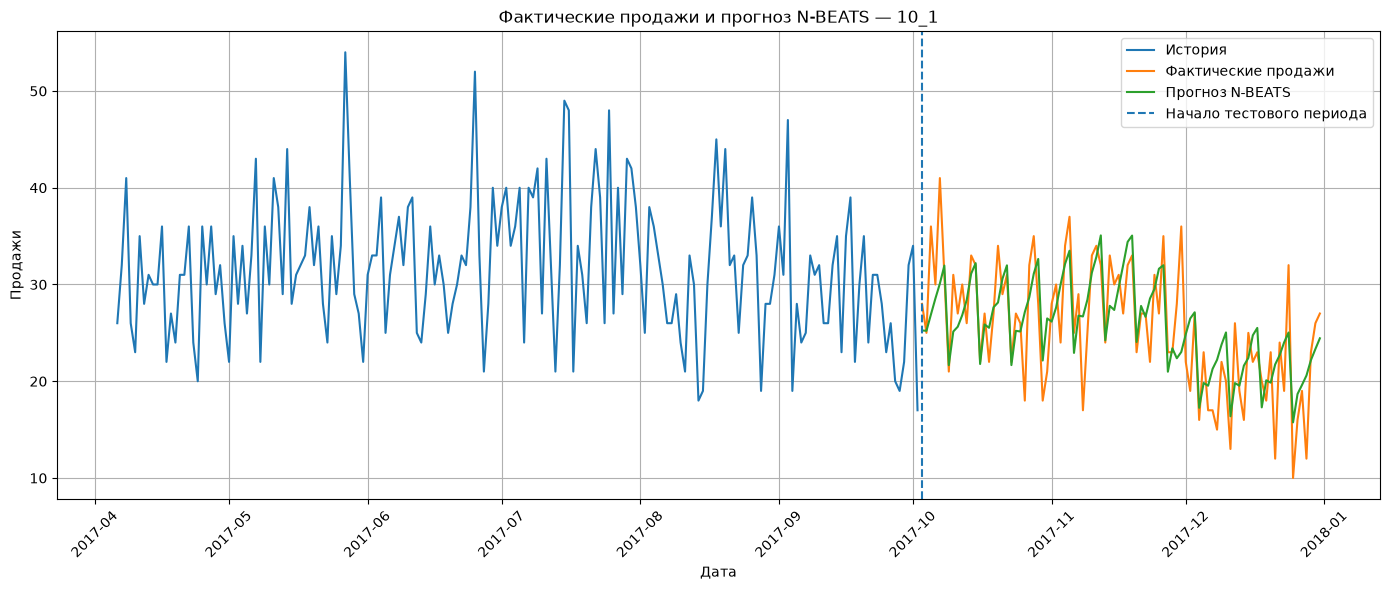

In [38]:
series_id = "10_1"

history = train_val_ts[
    train_val_ts["unique_id"] == series_id
].copy()

actual_series = test_ts[
    test_ts["unique_id"] == series_id
].copy()

forecast_series = pred_nbeats_test[
    pred_nbeats_test["unique_id"] == series_id
].copy()

history = history.sort_values("ds").tail(180)

plt.figure(figsize=(14, 6))

plt.plot(
    history["ds"],
    history["y"],
    label="История"
)

plt.plot(
    actual_series["ds"],
    actual_series["y"],
    label="Фактические продажи"
)

plt.plot(
    forecast_series["ds"],
    forecast_series["NBEATS"],
    label="Прогноз N-BEATS"
)

plt.axvline(
    actual_series["ds"].min(),
    linestyle="--",
    label="Начало тестового периода"
)

plt.title(
    f"Фактические продажи и прогноз N-BEATS — {series_id}"
)

plt.xlabel("Дата")
plt.ylabel("Продажи")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Допроверяем на тесте работу модели LSTM

In [72]:
nf_lstm_test = NeuralForecast(
    models=[
        LSTM(
            h=90,
            input_size=180,
            encoder_hidden_size=32,
            encoder_n_layers=1,
            decoder_hidden_size=32,
            decoder_layers=1,
            max_steps=300,
            scaler_type="standard"
        )
    ],
    freq="D"
)

nf_lstm_test.fit(train_val_ts)

Seed set to 1
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.

  | Name            | Type          | Params | Mode  | FLOPs
------------------------------------------------------------------
0 | loss            | MAE           | 0      | train | 0    
1 | padder          | ConstantPad1d | 0      | train | 0    
2 | scaler          | TemporalNorm  | 0      | train | 0    
3 | hist_encoder    | LSTM          | 4.5 K  | train | 0    
4 | context_adapter | Linear        | 29.7 K | train | 0    
5 | mlp_decoder     | MLP           | 385    | train | 0    
------------------------------------------------------------------
34.6 K    Trainable params
0         Non-trainable params
34.6 K    Total params
0.138     Total estimated model params

C:\Users\VTB\anaconda3\envs\ts_dl\Lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Epoch 6:  25%|██▌       | 4/16 [00:01<00:03,  3.18it/s, v_num=22, train_loss_step=0.655, train_loss_epoch=0.727] 
idation: |          | 0/? [00:00<?, ?it/s]
idation: |          | 0/? [00:00<?, ?it/s]
Epoch 12:  50%|█████     | 8/16 [00:02<00:02,  3.42it/s, v_num=22, train_loss_step=0.670, train_loss_epoch=0.704] 
idation: |          | 0/? [00:00<?, ?it/s]
idation: |          | 0/? [00:00<?, ?it/s]
Epoch 18: 100%|██████████| 12/12 [00:02<00:00,  4.07it/s, v_num=22, train_loss_step=0.678, train_loss_epoch=0.709]
idation: |          | 0/? [00:00<?, ?it/s]
idation: |          | 0/? [00:00<?, ?it/s]
Epoch 18: 100%|██████████| 12/12 [00:03<00:00,  3.78it/s, v_num=22, train_loss_step=0.678, train_loss_epoch=0.697]

`Trainer.fit` stopped: `max_steps=300` reached.


Epoch 18: 100%|██████████| 12/12 [00:03<00:00,  3.71it/s, v_num=22, train_loss_step=0.678, train_loss_epoch=0.697]


In [73]:
pred_lstm_test = nf_lstm_test.predict()

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
C:\Users\VTB\anaconda3\envs\ts_dl\Lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Predicting DataLoader 0: 100%|██████████| 16/16 [00:18<00:00,  0.88it/s]


In [76]:
eval_lstm_test, metrics_lstm_test = evaluate_forecast(
    test_ts,
    pred_lstm_test,
    "LSTM"
)


LSTM
MAE : 9.679518699645996
RMSE: 12.697516034726966
MAPE: 21.261834371525975


### Итоговая таблица с результатами ML и DL моделей

In [40]:
final_test_results = pd.DataFrame([
    {
        "Model": "Random Forest",
        "MAE": 6.371510,
        "RMSE": 8.344946,
        "MAPE": 13.989284
    },
    {
        "Model": "LightGBM",
        "MAE": 6.436233,
        "RMSE": 8.469791,
        "MAPE": 13.482989
    },
    {
        "Model": "XGBoost",
        "MAE": 6.506550,
        "RMSE": 8.577325,
        "MAPE": 13.483780
    },
    {
        "Model": "N-BEATS",
        "MAE": 6.203558,
        "RMSE": 8.084791,
        "MAPE": 13.568802
    },
    {
        "Model": "N-HITS",
        "MAE": 6.300983,
        "RMSE": 8.213886,
        "MAPE": 13.775434
    },
    {
        "Model": "LSTM",
        "MAE": 9.679519,
        "RMSE": 12.697516,
        "MAPE": 21.261834
    }
])

# Сортировка по MAE
final_test_results = final_test_results.sort_values(
    "MAE"
).reset_index(drop=True)

# Округление
final_test_results[["MAE", "RMSE", "MAPE"]] = (
    final_test_results[["MAE", "RMSE", "MAPE"]].round(3)
)

final_test_results

,Model,MAE,RMSE,MAPE
0,N-BEATS,6.204,8.085,13.569
1,N-HITS,6.301,8.214,13.775
2,Random Forest,6.372,8.345,13.989
3,LightGBM,6.436,8.470,13.483
4,XGBoost,6.507,8.577,13.484
5,LSTM,9.680,12.698,21.262


### Общий вывод

Таким образом,  N-BEATS показала наилучшую общую точность прогнозирования на тестовой выборке, тогда как среди классических ML-моделей наиболее эффективным оказался Random Forest.

## Задача 4 Подготовка пайплайна решения задачи предсказания ВР

In [30]:
import pandas as pd


def prepare_forecast_format(data):
    """
    Приводит исходный DataFrame
    к формату для прогнозирования временных рядов.
    """

    result = data.copy()

    # Уникальный идентификатор временного ряда
    result["unique_id"] = (
        result["store"].astype(str)
        + "_"
        + result["item"].astype(str)
    )

    # Переименовываем столбцы
    result = result.rename(
        columns={
            "date": "ds",
            "sales": "y"
        }
    )

    # Оставляем необходимые столбцы
    result = result[
        ["unique_id", "ds", "y"]
    ]

    # Сортировка
    result = (
        result
        .sort_values(["unique_id", "ds"])
        .reset_index(drop=True)
    )

    return result

In [2]:
# Одна функция для подготовки всех трех выборок
def prepare_datasets(train_df, val_df, test_df):

    train_ts = prepare_forecast_format(train_df)
    val_ts = prepare_forecast_format(val_df)
    test_ts = prepare_forecast_format(test_df)

    return train_ts, val_ts, test_ts

In [34]:
# Запускаем
train_ts, val_ts, test_ts = prepare_datasets(
    train_df,
    val_df,
    test_df
)

In [44]:
# Автоматическая проверка данных пайплайном
def check_datasets(train_ts, val_ts, test_ts):

    print("TRAIN")
    print("Строк:", len(train_ts))
    print("Рядов:", train_ts["unique_id"].nunique())
    print("Дней:", train_ts["ds"].nunique())

    print("\nVALIDATION")
    print("Строк:", len(val_ts))
    print("Рядов:", val_ts["unique_id"].nunique())
    print("Дней:", val_ts["ds"].nunique())

    print("\nTEST")
    print("Строк:", len(test_ts))
    print("Рядов:", test_ts["unique_id"].nunique())
    print("Дней:", test_ts["ds"].nunique())

    print("\nПроверка пропусков:")
    print("Train:", train_ts.isna().sum().sum())
    print("Validation:", val_ts.isna().sum().sum())
    print("Test:", test_ts.isna().sum().sum())

check_datasets(train_ts, val_ts, test_ts)

TRAIN
Строк: 823000
Рядов: 500
Дней: 1646

VALIDATION
Строк: 45000
Рядов: 500
Дней: 90

TEST
Строк: 45000
Рядов: 500
Дней: 90

Проверка пропусков:
Train: 0
Validation: 0
Test: 0


In [45]:
# Проверка на пересечение
print(
    "Пересечение train/validation:",
    len(set(train_ts["ds"]) & set(val_ts["ds"]))
)

print(
    "Пересечение validation/test:",
    len(set(val_ts["ds"]) & set(test_ts["ds"]))
)


Пересечение train/validation: 0
Пересечение validation/test: 0


In [46]:
# Проверка на пропуски
print("Пропуски:")
print(train_ts.isna().sum())
print(val_ts.isna().sum())
print(test_ts.isna().sum())

Пропуски:
unique_id    0
ds           0
y            0
dtype: int64
unique_id    0
ds           0
y            0
dtype: int64
unique_id    0
ds           0
y            0
dtype: int64


In [47]:
# На отрицательные значения
print("Отрицательные значения sales:")
print("Train:", (train_ts["y"] < 0).sum())
print("Validation:", (val_ts["y"] < 0).sum())
print("Test:", (test_ts["y"] < 0).sum())

Отрицательные значения sales:
Train: 0
Validation: 0
Test: 0


На первом этапе выполняется подготовка исходных данных для прогнозирования. Для каждой пары «магазин–товар» формируется отдельный временной ряд с уникальным идентификатором unique_id. Дата преобразуется в формат ds, целевая переменная продаж — в y. Полученные временные ряды сортируются по идентификатору и дате. Данные разделяются на обучающую, валидационную и тестовую выборки. Горизонт прогнозирования составляет 90 дней.

In [35]:
# Функция расчета основных метрик для оценки моделей
import numpy as np

def calculate_metrics(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    mae = np.mean(np.abs(y_true - y_pred))

    rmse = np.sqrt(
        np.mean((y_true - y_pred) ** 2)
    )

    mask = y_true != 0

    mape = np.mean(
        np.abs(
            (y_true[mask] - y_pred[mask]) /
            y_true[mask]
        )
    ) * 100

    return {
        "MAE": mae,
        "RMSE": rmse,
        "MAPE": mape
    }

In [49]:
# Проверка
metrics_nhits_val = calculate_metrics(
    eval_nhits["y"],
    eval_nhits["NHITS"]
)

print(metrics_nhits_val)

{'MAE': np.float64(6.909413090451558), 'RMSE': np.float64(8.938484289107315), 'MAPE': np.float64(12.177833371812813)}


In [36]:
#Универсальная функция расчета метрик
def evaluate_forecast(actual, forecast, model_name):

    df = actual.merge(
        forecast,
        on=["unique_id", "ds"],
        how="inner"
    )

    metrics = calculate_metrics(
        df["y"],
        df[model_name]
    )

    print(f"\n{model_name}")
    print("MAE :", metrics["MAE"])
    print("RMSE:", metrics["RMSE"])
    print("MAPE:", metrics["MAPE"])

    return df, metrics

In [51]:
# Проверка
eval_nhits_val, metrics_nhits_val = evaluate_forecast(
    val_ts,
    pred_nhits,
    "NHITS"
)


NHITS
MAE : 6.909413090451558
RMSE: 8.938484289107315
MAPE: 12.177833371812813


In [52]:
# Формируем данные для Train и Validation
train_val_ts = pd.concat(
    [train_ts, val_ts],
    ignore_index=True
).sort_values(
    ["unique_id", "ds"]
).reset_index(drop=True)

In [53]:
print("Train + Validation")
print("Строк:", len(train_val_ts))
print("Рядов:", train_val_ts["unique_id"].nunique())
print("Дней:", train_val_ts["ds"].nunique())

Train + Validation
Строк: 868000
Рядов: 500
Дней: 1736


## Универсальная модель пайплайна 

In [39]:
def run_nbeats_pipeline(train_df, val_df, test_df):

    # 1. Подготовка данных
    train_ts = prepare_forecast_format(train_df)
    val_ts = prepare_forecast_format(val_df)
    test_ts = prepare_forecast_format(test_df)

    # 2. Объединяем train и validation
    train_val_ts = pd.concat(
        [train_ts, val_ts],
        ignore_index=True
    ).sort_values(
        ["unique_id", "ds"]
    ).reset_index(drop=True)

    # 3. Создаём N-BEATS
    model = NBEATS(
        h=90,
        input_size=180,
        max_steps=500,
        learning_rate=1e-3,
        batch_size=32,
        scaler_type="standard",
        random_seed=42
    )

    # 4. Создаём NeuralForecast
    nf = NeuralForecast(
        models=[model],
        freq="D"
    )

    # 5. Обучение
    nf.fit(train_val_ts)

    # 6. Прогноз
    forecast = nf.predict()

    # 7. Оценка
    evaluation = test_ts.merge(
        forecast,
        on=["unique_id", "ds"],
        how="inner"
    )

    metrics = calculate_metrics(
        evaluation["y"],
        evaluation["NBEATS"]
    )

    return nf, forecast, evaluation, metrics

### Запускаем пайплайн, заново обучаем, проверяем результат

In [40]:
nf_final, forecast_final, evaluation_final, metrics_final = run_nbeats_pipeline(
    train_df,
    val_df,
    test_df
)

Seed set to 42
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.

  | Name         | Type          | Params | Mode  | FLOPs
---------------------------------------------------------------
0 | loss         | MAE           | 0      | train | 0    
1 | padder_train | ConstantPad1d | 0      | train | 0    
2 | scaler       | TemporalNorm  | 0      | train | 0    
3 | blocks       | ModuleList    | 3.0 M  | train | 0    
---------------------------------------------------------------
3.0 M     Trainable params
48.9 K    Non-trainable params
3.0 M     Total params
12.060    Total estimated model params size (MB)
31        Modules in train mode
0         Modules in eval mode
0         Total Flops


C:\Users\VTB\anaconda3\envs\ts_dl\Lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Epoch 6:  25%|██▌       | 4/16 [00:01<00:05,  2.32it/s, v_num=13, train_loss_step=0.536, train_loss_epoch=0.552] 
idation: |          | 0/? [00:00<?, ?it/s]
idation: |          | 0/? [00:00<?, ?it/s]
Epoch 12:  50%|█████     | 8/16 [00:03<00:03,  2.16it/s, v_num=13, train_loss_step=0.511, train_loss_epoch=0.526] 
idation: |          | 0/? [00:00<?, ?it/s]
idation: |          | 0/? [00:00<?, ?it/s]
Epoch 18:  75%|███████▌  | 12/16 [00:06<00:02,  1.75it/s, v_num=13, train_loss_step=0.520, train_loss_epoch=0.525]
idation: |          | 0/? [00:00<?, ?it/s]
idation: |          | 0/? [00:00<?, ?it/s]
Epoch 24: 100%|██████████| 16/16 [00:08<00:00,  1.84it/s, v_num=13, train_loss_step=0.515, train_loss_epoch=0.521]
idation: |          | 0/? [00:00<?, ?it/s]
idation: |          | 0/? [00:00<?, ?it/s]
Epoch 31: 100%|██████████| 4/4 [00:01<00:00,  2.09it/s, v_num=13, train_loss_step=0.530, train_loss_epoch=0.520]  
idation: |          | 0/? [00:00<?, ?it/s]
idation: |          | 0/? [00:00<?, ?it

`Trainer.fit` stopped: `max_steps=500` reached.


Epoch 31: 100%|██████████| 4/4 [00:02<00:00,  1.79it/s, v_num=13, train_loss_step=0.530, train_loss_epoch=0.516]


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
C:\Users\VTB\anaconda3\envs\ts_dl\Lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Predicting DataLoader 0: 100%|██████████| 16/16 [00:00<00:00, 63.38it/s]


In [41]:
print("ФИНАЛЬНЫЕ РЕЗУЛЬТАТЫ N-BEATS")
print("=" * 40)

print("MAE :", metrics_final["MAE"])
print("RMSE:", metrics_final["RMSE"])
print("MAPE:", metrics_final["MAPE"])

ФИНАЛЬНЫЕ РЕЗУЛЬТАТЫ N-BEATS
MAE : 6.203558226776123
RMSE: 8.084791449879988
MAPE: 13.568802156428134


### Итоговая таблица с результатами

In [42]:
results = pd.DataFrame({
    "Модель": [
        "Random Forest",
        "XGBoost",
        "LightGBM",
        "N-BEATS",
        "N-HITS"
    ],
    "MAE": [
        7.324215,
        8.563787,
        8.911380,
        6.203558,
        6.300983
    ],
    "RMSE": [
        9.407694,
        10.891761,
        11.098617,
        8.084791,
        8.213886
    ],
    "MAPE, %": [
        13.448633,
        15.988378,
        17.485047,
        13.568802,
        13.775434
    ]
})

results = results.sort_values("MAE").reset_index(drop=True)

results

,Модель,MAE,RMSE,"MAPE, %"
0,N-BEATS,6.203558,8.084791,13.568802
1,N-HITS,6.300983,8.213886,13.775434
2,Random Forest,7.324215,9.407694,13.448633
3,XGBoost,8.563787,10.891761,15.988378
4,LightGBM,8.911380,11.098617,17.485047


### Выводы

В рамках четвертой задачи был разработан pipeline прогнозирования временных рядов продаж. Исходные данные были преобразованы в формат, содержащий идентификатор временного ряда `unique_id`, дату `ds` и целевую переменную `y`. Данные были разделены на обучающую, валидационную и тестовую выборки. Горизонт прогнозирования составил 90 дней.

На этапе выбора модели были рассмотрены методы машинного обучения Random Forest, XGBoost и LightGBM, а также глубокие нейросетевые модели N-BEATS и N-HITS. Качество прогнозирования оценивалось с использованием метрик MAE, RMSE и MAPE.

По результатам тестирования наилучшие значения MAE и RMSE показала модель N-BEATS: MAE = 6.20 и RMSE = 8.08. MAPE модели составил 13.57%. Для сравнения, у Random Forest значения MAE и RMSE составили 7.32 и 9.41 соответственно. Таким образом, использование N-BEATS позволило снизить MAE примерно на 15.3%, а RMSE примерно на 14.1% относительно Random Forest. 

При этом минимальное значение MAPE среди рассмотренных моделей показал Random Forest — 13.45%. Разница с N-BEATS составляет около 0.22 процентного пункта, поэтому по совокупности основных показателей N-BEATS была выбрана в качестве итоговой модели. Небольшое преимущество модели Random Forest перед N-BEATS по MAPE отчасти можно объяснить тем, что первая модель лучше оптимизирует относительную ошибку , модель может очень хорошо воспроизводить локальный уровень продаж. При этом в абсолютном значении N-BEATS отклоняется меньше и работает точнее.

Для выбранной модели был реализован автоматизированный pipeline, включающий подготовку данных, объединение обучающей и валидационной выборок, создание и обучение модели N-BEATS, построение 90-дневного прогноза и автоматический расчет метрик качества.

Разработанный pipeline позволяет воспроизводимо выполнять полный цикл прогнозирования и может быть использован для повторного обучения модели и получения прогнозов при поступлении новых данных.